In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots appear inside the notebook
%matplotlib inline

# Load the data
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
# See the first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

print(missing_df[missing_df["missing_count"] > 0 ])

          missing_count  missing_pct
Age                 177         19.9
Cabin               687         77.1
Embarked              2          0.2


In [9]:
# Age - fill with median
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)
print(f"Filled Age with median: {median_age}")

# Embarked - only 2 missing, fill with most common value
most_common_port = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(most_common_port)
print(f"Filled Embarked with mode: {most_common_port}")

# Cabin - too many missing, drop the column entirely
df = df.drop(columns=["Cabin"])
print(f"Dropped Cabin column")

# Verify - should be 0 missing everywhere now
print(f"\nMissing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Done - no missing values" if df.isnull().sum().sum() == 0 else "Still has missing values")

Filled Age with median: 28.0
Filled Embarked with mode: S
Dropped Cabin column

Missing values remaining:
Series([], dtype: int64)
Done - no missing values


In [15]:
# Overall survival rate
survival_rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Survival by sex
print("\nSurvival rate by sex:")
print(df.groupby("Sex")["Survived"].mean().mul(100).round(1))

# Survival by passenger class
print("\nSurvival rate by class:")
print(df.groupby("Pclass")["Survived"].mean().mul(100).round(1))

# Survival by sex AND class combined
print("\nSurvival rate by sex and class:")
print(df.groupby(["Sex", "Pclass"])["Survived"].mean().mul(100).round(1))

Overall survival rate: 38.4%

Survival rate by sex:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

Survival rate by class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64

Survival rate by sex and class:
Sex     Pclass
female  1         96.8
        2         92.1
        3         50.0
male    1         36.9
        2         15.7
        3         13.5
Name: Survived, dtype: float64


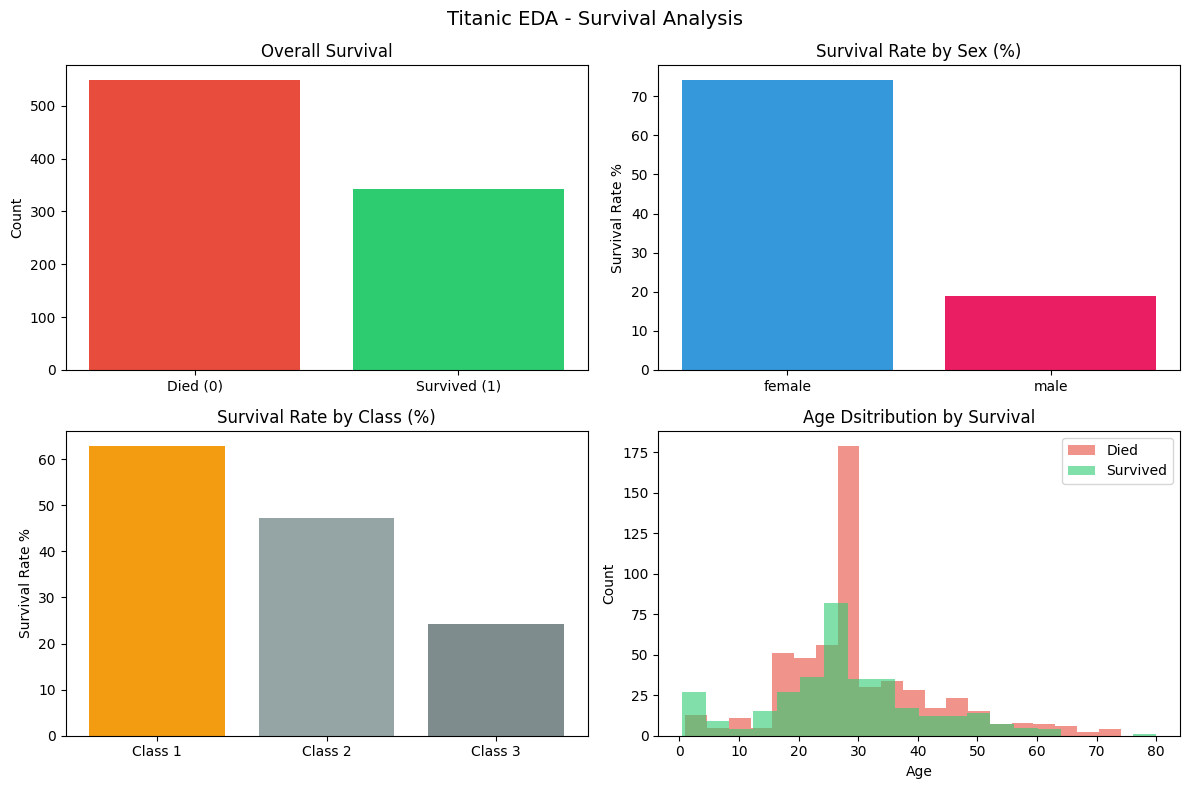

Chart saved as survival_analysis.png


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Titanic EDA - Survival Analysis", fontsize=14)

# Chart 1 - Survival count
axes[0, 0].bar(["Died (0)", "Survived (1)"],
               df["Survived"].value_counts().sort_index(),
               color=["#e74c3c", "#2ecc71"])
axes[0, 0].set_title("Overall Survival")
axes[0, 0].set_ylabel("Count")

# Chart 2 - Survival by sex
sex_survival = df.groupby("Sex")["Survived"].mean() * 100
axes[0, 1].bar(sex_survival.index, sex_survival.values,
              color=["#3498db", "#e91e63"])
axes[0, 1].set_title("Survival Rate by Sex (%)")
axes[0, 1].set_ylabel("Survival Rate %")

# Chart 3 - Survival by class
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
axes[1, 0].bar([f"Class {c}" for c in class_survival.index],
               class_survival.values,
               color=["#f39c12", "#95a5a6", "#7f8c8d"])
axes[1, 0].set_title("Survival Rate by Class (%)")
axes[1, 0].set_ylabel("Survival Rate %")

# Chart 4 - Age distribution by survival
axes[1, 1].hist(df[df["Survived"] == 0]["Age"], bins=20,
                alpha=0.6, label="Died", color="#e74c3c")
axes[1, 1].hist(df[df["Survived"] == 1]["Age"], bins=20,
                alpha=0.6, label="Survived", color="#2ecc71")
axes[1, 1].set_title("Age Dsitribution by Survival")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("survival_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as survival_analysis.png")

In [27]:
# Age statistics by survival
print("Age statistics by survival:")
print(df.groupby("Survived")["Age"].describe().round(1))

print("\nFare statistics by survival:")
print(df.groupby("Survived")["Fare"].describe().round(1))

# Correlation between numerical columns
print("\nCorrelation with Survived:")
numerical_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch"]
correlations = df[numerical_cols + ["Survived"]].corr()["Survived"].drop("Survived")
print(correlations.round(3).sort_values())

Age statistics by survival:
          count  mean   std  min   25%   50%   75%   max
Survived                                                
0         549.0  30.0  12.5  1.0  23.0  28.0  35.0  74.0
1         342.0  28.3  13.8  0.4  21.0  28.0  35.0  80.0

Fare statistics by survival:
          count  mean   std  min   25%   50%   75%    max
Survived                                                 
0         549.0  22.1  31.4  0.0   7.9  10.5  26.0  263.0
1         342.0  48.4  66.6  0.0  12.5  26.0  57.0  512.3

Correlation with Survived:
Pclass   -0.338
Age      -0.065
SibSp    -0.035
Parch     0.082
Fare      0.257
Name: Survived, dtype: float64


In [33]:
print("=" * 55)
print("TITANIC EEDA - KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
DATASET
  passenger:       {len(df)}
  Features:        {df.shape[1]}
  Survival rate:   {df['Survived'].mean()*100:.1f}%

MISSING VALUES HANDLED
  Age:   filled with median ({df['Age'].median():.0f} years)
  Cabin: dropped (77% missing)
  Embarked: filled with mode (S)

KEY PATTERNS FOUND
  Women survived at {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%
  Men survived at {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%
  
  1st class: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}% survival
  2nd class: {df[df['Pclass']==2]['Survived'].mean()*100:.1f}% survival
  3rd class: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}% survival

  Children (under 10) had higher survival than adults
  Higher fare = higher survival (correlation: {df['Fare'].corr(df['Survived']):.3f})
  Higher class number = lower survival (correlation: {df['Pclass'].corr(df['Survived']):.3f})

STRONGEST PREDICTORS FOR A MODEL
  1. Sex         (biggest single factor)
  2. Pclass      (strong negative correlation)
  3. Fare        (strong positive correlation)
  4. Age         (children prioritised)
""")
# Save cleaned dataset
df.to_csv("titanic_clean.csv", index=False)
print("Saved cleaned dataset to titanic_clean.csv")

TITANIC EEDA - KEY FINDINGS SUMMARY

DATASET
  passenger:       891
  Features:        11
  Survival rate:   38.4%

MISSING VALUES HANDLED
  Age:   filled with median (28 years)
  Cabin: dropped (77% missing)
  Embarked: filled with mode (S)

KEY PATTERNS FOUND
  Women survived at 74.2%
  Men survived at 18.9%

  1st class: 63.0% survival
  2nd class: 47.3% survival
  3rd class: 24.2% survival

  Children (under 10) had higher survival than adults
  Higher fare = higher survival (correlation: 0.257)
  Higher class number = lower survival (correlation: -0.338)

STRONGEST PREDICTORS FOR A MODEL
  1. Sex         (biggest single factor)
  2. Pclass      (strong negative correlation)
  3. Fare        (strong positive correlation)
  4. Age         (children prioritised)

Saved cleaned dataset to titanic_clean.csv
